In [ ]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("sachinkumar413/covid-pneumonia-normal-chest-xray-images")

print("Path to dataset files:", path) #path to the dataset

100%|██████████| 277M/277M [00:03<00:00, 79.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sachinkumar413/covid-pneumonia-normal-chest-xray-images/versions/1


In [ ]:
# Imports used

import os
import random
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


this was done for screenshot purposes for report

In [ ]:
import os

DATA_DIR = path

class_names = [d for d in sorted(os.listdir(DATA_DIR)) if os.path.isdir(os.path.join(DATA_DIR, d))]
print("Classes found:", class_names)

# show a few files from each class
for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".jpeg",".png"))]
    print(f"{cls:>15}: {len(files)} images | example: {files[:3]}")


Classes found: ['COVID', 'NORMAL', 'PNEUMONIA']
          COVID: 1626 images | example: ['COVID_762.png', 'COVID_850.png', 'COVID_1181.png']
         NORMAL: 1802 images | example: ['NORMAL_1438.png', 'NORMAL_946.png', 'NORMAL_639.png']
      PNEUMONIA: 1800 images | example: ['PNEUMONIA_1330.png', 'PNEUMONIA_1629.png', 'PNEUMONIA_1775.png']


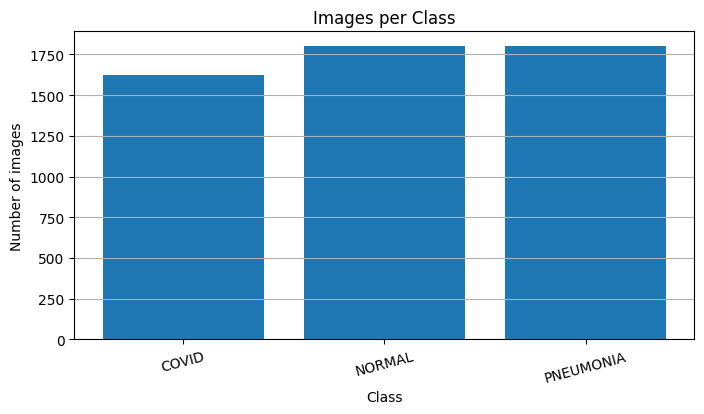

In [ ]:
import matplotlib.pyplot as plt

counts = []
for cls in class_names:s
    cls_path = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".jpeg",".png"))]
    counts.append(len(files))

plt.figure(figsize=(8,4))
plt.bar(class_names, counts)
plt.title("Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=15)
plt.grid(True, axis="y")
plt.show()
#shows how many images per class

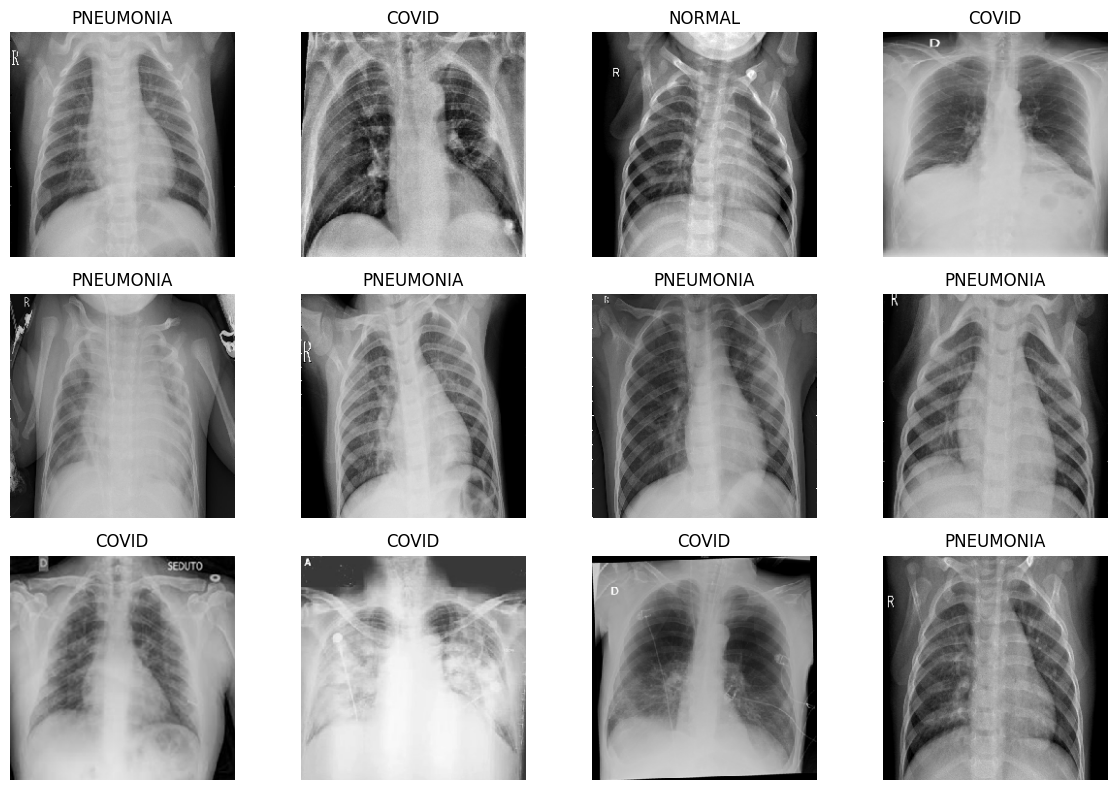

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

rows, cols = 3, 4
plt.figure(figsize=(12,8))

for i in range(rows * cols):
    cls = random.choice(class_names)
    cls_path = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".jpeg",".png"))]
    img_path = os.path.join(cls_path, random.choice(files))

    img = Image.open(img_path).convert("RGB")
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()
# some examples of the images that are in the dataset

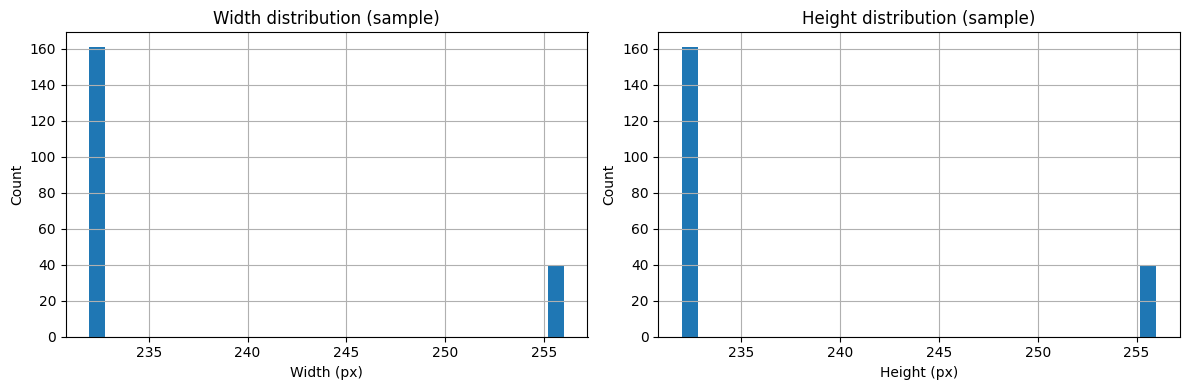

Sample size stats:
Width  min/median/max: 232 232 256
Height min/median/max: 232 232 256


In [ ]:
import numpy as np
from PIL import Image

sample_n = 200  # number of images for analysis
sizes = []

all_paths = []
for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".jpeg",".png"))]
    all_paths.extend([os.path.join(cls_path, f) for f in files])

random.shuffle(all_paths)
all_paths = all_paths[:min(sample_n, len(all_paths))]

for p in all_paths:
    try:
        with Image.open(p) as im:
            sizes.append(im.size)  # (width, height)
    except:
        pass

w = [s[0] for s in sizes]
h = [s[1] for s in sizes]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(w, bins=30)
plt.title("Width distribution (sample)")
plt.xlabel("Width (px)")
plt.ylabel("Count")
plt.grid(True)

plt.subplot(1,2,2)
plt.hist(h, bins=30)
plt.title("Height distribution (sample)")
plt.xlabel("Height (px)")
plt.ylabel("Count")
plt.grid(True)

plt.tight_layout()
plt.show()

print("Sample size stats:")
print("Width  min/median/max:", min(w), int(np.median(w)), max(w))
print("Height min/median/max:", min(h), int(np.median(h)), max(h))
# shows the width and height of the images

In [ ]:
from PIL import Image # Used to load and inspect images
import numpy as np

p = random.choice(all_paths) # Picks a random image from the dataset
img = Image.open(p)
arr = np.array(img)

print("Example file:", p)
print("Mode:", img.mode) # Shows whether the image is grayscale or RGB
print("Array shape:", arr.shape)  # grayscale often (H,W), RGB (H,W,3)


Example file: /root/.cache/kagglehub/datasets/sachinkumar413/covid-pneumonia-normal-chest-xray-images/versions/1/NORMAL/NORMAL_1228.png
Mode: RGB
Array shape: (232, 232, 3)


In [ ]:
import tensorflow as tf
import numpy as np
import random

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Define training parameters

IMG_SIZE = (224, 224) # Target size for all input images
BATCH_SIZE = 32  # Number of images processed at once
EPOCHS = 15   # Number of training iterations over the dataset


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=8,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.08,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

num_classes = len(train_gen.class_indices)
print("Classes:", train_gen.class_indices)


Found 4183 images belonging to 3 classes.
Found 1045 images belonging to 3 classes.
Classes: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()
# Displays the model architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#callback to control training
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]
#training the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 65s 437ms/step - accuracy: 0.6895 - loss: 0.7193 - val_accuracy: 0.9388 - val_loss: 0.2094 - learning_rate: 0.0010
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 398ms/step - accuracy: 0.8843 - loss: 0.3234 - val_accuracy: 0.9349 - val_loss: 0.1746 - learning_rate: 0.0010
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 51s 392ms/step - accuracy: 0.9043 - loss: 0.2661 - val_accuracy: 0.9560 - val_loss: 0.1313 - learning_rate: 0.0010
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 394ms/step - accuracy: 0.9225 - loss: 0.2313 - val_accuracy: 0.9522 - val_loss: 0.1265 - learning_rate: 0.0010
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 394ms/step - accuracy: 0.9176 - loss: 0.2307 - val_accuracy: 0.9598 - val_loss: 0.1110 - learning_rate: 0.0010
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 396ms/step - accuracy: 0.9260 - loss: 0.2130 - val_accuracy: 0.9550 - val_loss: 0.1261 - learning_rate: 0.0010
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 395ms/step - accuracy: 0.9

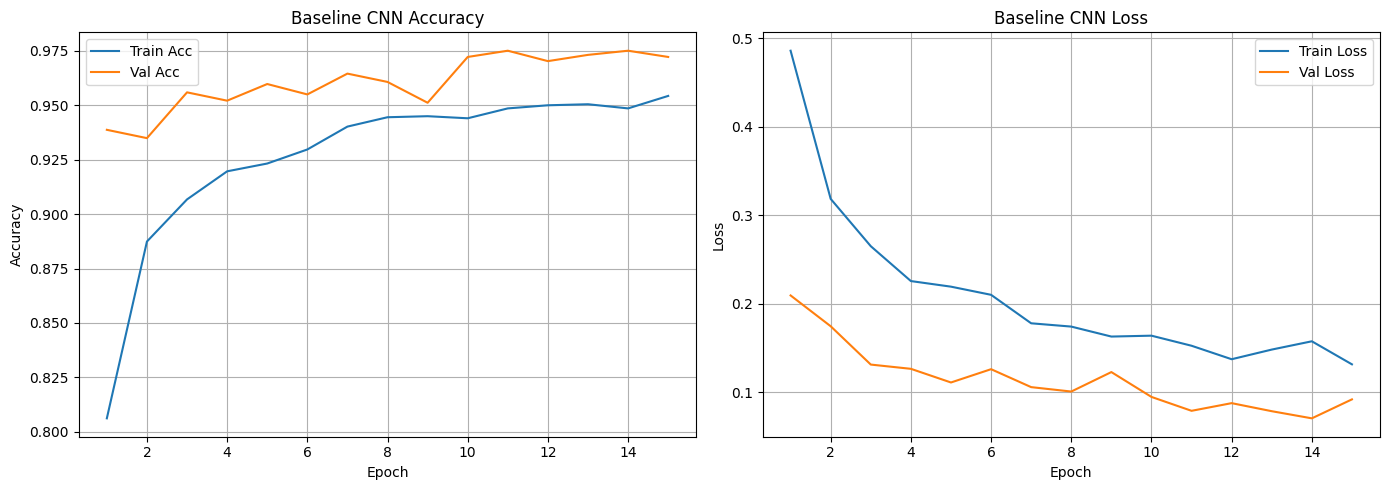

In [ ]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label="Train Acc")
plt.plot(epochs, val_acc, label="Val Acc")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)Z
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()
#graph to show visual representation on the first model which is the baseline cnn model

okay so with the first model, this is a simple baseline model to see how it works and it will be the baseline to judge and compare the next models we will look at to see how much more advanced models compare to a baseline model.

the pros are that it shows fast learning with high accuracy and the validation and training accuracy is consistent as loss decreases slowly without huge suddent spikes.

the cons are that training accuracy is alot slower than validation accuracy and also there is a slight increase with validation loss in later epochs and the model is not that advanced which means performance will plateau compared to more advanced models.

deep learning cnn now

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(train_gen.class_indices)

deep_model2 = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

deep_model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deep_model2.summary()
# Displays the model architecture

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,234,499 (50.49 MB)

 Trainable params: 13,234,499 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
#callbacks to control and save the best verison of the model
callbacks = [
    ModelCheckpoint("best_deep_cnn.keras", monitor="val_accuracy", mode="max",
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_accuracy", mode="max", patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2,
                      min_lr=1e-7, verbose=1),
]
#training the deep ccn model
history_deep2 = deep_model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.5969 - loss: 0.8332
Epoch 1: val_accuracy improved from -inf to 0.91962, saving model to best_deep_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 62s 437ms/step - accuracy: 0.5979 - loss: 0.8317 - val_accuracy: 0.9196 - val_loss: 0.2516 - learning_rate: 1.0000e-04
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.8608 - loss: 0.3539
Epoch 2: val_accuracy improved from 0.91962 to 0.94737, saving model to best_deep_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 401ms/step - accuracy: 0.8610 - loss: 0.3537 - val_accuracy: 0.9474 - val_loss: 0.1805 - learning_rate: 1.0000e-04
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.8967 - loss: 0.2811
Epoch 3: val_accuracy did not improve from 0.94737
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 402ms/step - accuracy: 0.8967 - loss: 0.2812 - val_accuracy: 0.9397 - val_loss: 0.1820 - learning_rate: 1.0000e-04
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accu

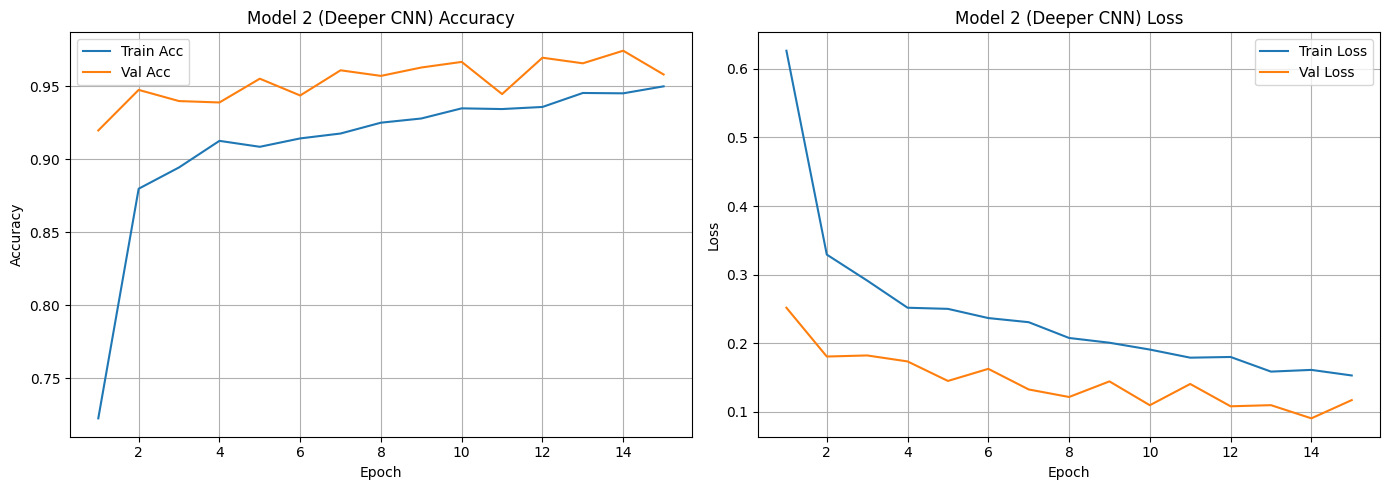

In [ ]:
import matplotlib.pyplot as plt

acc = history_deep2.history["accuracy"]
val_acc = history_deep2.history["val_accuracy"]
loss = history_deep2.history["loss"]
val_loss = history_deep2.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label="Train Acc")
plt.plot(epochs, val_acc, label="Val Acc")
plt.title("Model 2 (Deeper CNN) Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.title("Model 2 (Deeper CNN) Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


this is a deeper cnn model from model 1 and includes more layers and improved callbacks which helps to capture more complex image features.


pros from this model is it has a slightly higher validation accuracy and also validation remains low and stable after the fluctuation at the start. It also has better feature extraction compared to baseline model.


the cons are that it has noticleable fluctuation and has a risk of overfitting due to increased model complexity and it also took longer to train compared to baseline cnn model.

model 3

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import kagglehub
import random
import numpy as np


#imports


In [ ]:
path = kagglehub.dataset_download( "sachinkumar413/covid-pneumonia-normal-chest-xray-images")

DATASET_DIR = path
#configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Dataset path:", DATASET_DIR)


Using Colab cache for faster access to the 'covid-pneumonia-normal-chest-xray-images' dataset.
Dataset path: /kaggle/input/covid-pneumonia-normal-chest-xray-images


In [ ]:
# Data generator with preprocessing for VGG16
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)
#number of classes
NUM_CLASSES = train_gen.num_classes
print("Classes:", train_gen.class_indices)


Found 4183 images belonging to 3 classes.
Found 1045 images belonging to 3 classes.
Classes: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}


In [ ]:
base_model = VGG16( #loading the pretrained model
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model_tl = Model(inputs=base_model.input, outputs=outputs)

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_tl.summary()
# model architecture

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
] # controlling callback to prevent overfitting



In [ ]:
history_tl = model_tl.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)
#training the transfer learning model

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 727ms/step - accuracy: 0.5682 - loss: 2.1600 - val_accuracy: 0.9196 - val_loss: 0.2883 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 481ms/step - accuracy: 0.8406 - loss: 0.5480 - val_accuracy: 0.9244 - val_loss: 0.2620 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 483ms/step - accuracy: 0.8746 - loss: 0.3957 - val_accuracy: 0.9349 - val_loss: 0.2038 - learning_rate: 1.0000e-04
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 483ms/step - accuracy: 0.9054 - loss: 0.2885 - val_accuracy: 0.9388 - val_loss: 0.1910 - learning_rate: 1.0000e-04
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 486ms/step - accuracy: 0.9072 - loss: 0.2812 - val_accuracy: 0.9445 - val_loss: 0.1767 - learning_rate: 1.0000e-04
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 483ms/step - accuracy: 0.9194 - loss: 0.2318 - val_accuracy: 0.9388 - val_loss: 0.1827 - learning_rate: 1.0000e-04
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 4

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
# imports

In [ ]:
# Get true labels
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

# Predict
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)



33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step


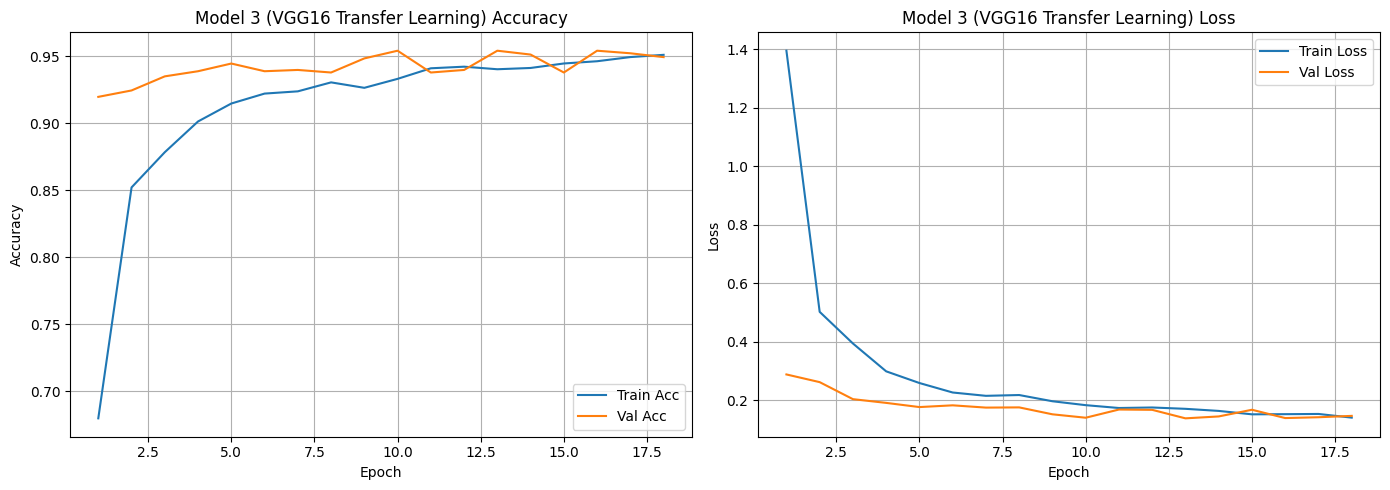

In [ ]:
import matplotlib.pyplot as plt

acc = history_tl.history["accuracy"]
val_acc = history_tl.history["val_accuracy"]
loss = history_tl.history["loss"]
val_loss = history_tl.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc, label="Train Acc")
plt.plot(epochs, val_acc, label="Val Acc")
plt.title("Model 3 (VGG16 Transfer Learning) Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.title("Model 3 (VGG16 Transfer Learning) Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



model 3 overview is that i used a vgg16 model which is trained on imageNet.

the pros on this model are that it is very stable with smooth accuracy and loss curves and has high accuracy which is consistent and does not have spikes like model 2. it also requires less trainable parameters compared to model 2 which is good but the cons for this model are that it takes very long to train and it has limited ability to adapt features because base model is frozen. it also has a way higher usage compared to baseline model and it also just has slightly better if not the same accuracy as model 2 but we have to take into account it is alot more stable which is also important when training models.